# Week 2 — Task 3: Cognitive load and the data-ink ratio

**Data:** `data/car_crashes.csv` (51 rows: 50 states + DC) and `data/tips.csv` (244 restaurant bills).

No human experiment is required for this task — it's entirely about load and ink.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette ---------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"

# Context grey + ink. Week 2's rule: "grey is a colour choice" - context
# goes grey, the message gets ONE strong colour.
GREY = "#bbbbbb"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name, dpi=150):
    # Regular charts: 150 dpi is plenty and keeps notebooks small.
    # Task 5's final export is re-saved separately at the required 300 dpi.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE, dpi=dpi, bbox_inches="tight")


def footnote(ax, text, y=-0.2):
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load the data

In [2]:
cc = pd.read_csv(DATA / "car_crashes.csv")
tips = pd.read_csv(DATA / "tips.csv")
print("car_crashes:", cc.shape, " tips:", tips.shape)
print("Missing values - crashes:", int(cc.isna().sum().sum()), " tips:", int(tips.isna().sum().sum()))
cc.head(3)

car_crashes: (51, 8)  tips: (244, 7)
Missing values - crashes: 0  tips: 0


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ


Nothing missing in either file, so **no rows are excluded** anywhere in this notebook.

Note up front: `total`, the percentage columns (`speeding`, `alcohol`, `not_distracted`, `no_previous`) and
the dollar columns (`ins_premium`, `ins_losses`) are in **three different units**. Only `total` is used for
the bar charts below — mixing the others onto one axis would be a Week 1 zero-baseline/units violation, not
a load problem, so it's avoided throughout.

---
## Step 1 — build an overloaded chart on purpose

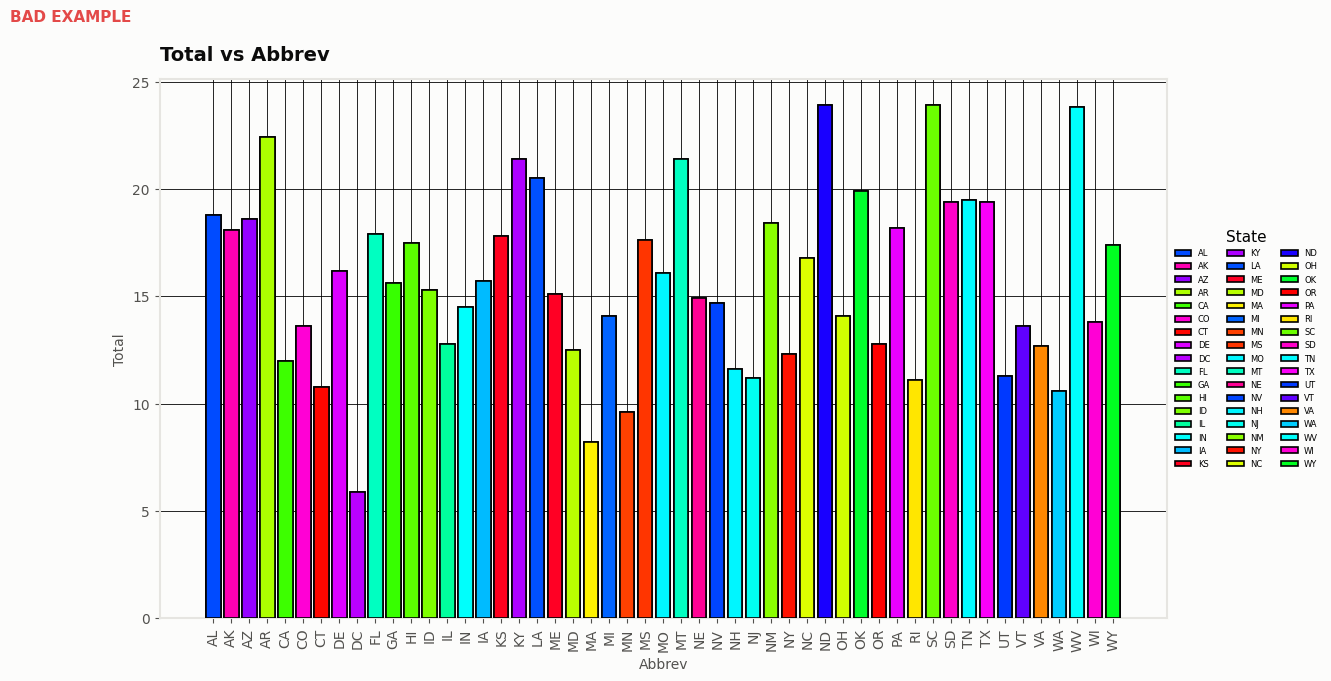

In [3]:
# =====================================================================
#  BAD EXAMPLE - every extraneous-load trick in the book, on purpose.
# =====================================================================
rng = np.random.default_rng(7)
rainbow = plt.cm.hsv(rng.uniform(0, 1, len(cc)))   # a different, meaningless colour per bar

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(cc["abbrev"], cc["total"], color=rainbow, edgecolor="black", linewidth=1.2, zorder=3)

# fake drop-shadow: a second, offset, dark copy of every bar
for abbr, val in zip(cc["abbrev"], cc["total"]):
    ax.bar(abbr, val, color="black", alpha=0.25, zorder=2,
           width=0.9, align="center", bottom=0, hatch=None,
           linewidth=0, )
ax.bar(cc["abbrev"], cc["total"], color=rainbow, edgecolor="black", linewidth=1.2, zorder=3)  # redraw on top

ax.set_title("Total vs Abbrev", fontsize=14)          # names the axes, states no finding
ax.set_xlabel("Abbrev")
ax.set_ylabel("Total")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, which="both", axis="both", color="black", linewidth=0.6)   # heavy grid, both directions
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(True)                 # full box frame
    ax.spines[side].set_linewidth(1.5)
ax.legend(bars, cc["abbrev"], loc="center left", bbox_to_anchor=(1.0, 0.5),
          ncol=3, fontsize=6, title="State")           # a 51-entry legend

fig.suptitle("BAD EXAMPLE", x=0.01, ha="left", fontsize=11, color=RED, fontweight="bold")
save(fig, "t3_bad_example", dpi=150)
plt.show()

**The one question a reader should be able to answer from this chart:** *"which states have the highest
total crash rate, and how does my state compare?"* They effectively cannot — by the time they've decoded
51 rotated labels against a 51-entry legend of near-identical hues, matched each bar back to its colour
key, and filtered out the heavy grid and fake shadow, the comparison the chart exists to support has been
buried under work that has nothing to do with the data.

---
## Step 2 — count the load

In [4]:
load = pd.DataFrame([
    {"element": "51 bars (height = total)",            "type": "intrinsic",  "note": "the data itself"},
    {"element": "51 rainbow bar colours",               "type": "extraneous", "note": "colour encodes nothing - each state just gets the next hue"},
    {"element": "51 fake drop-shadow bars",              "type": "extraneous", "note": "pure decoration, doubles the bar ink for zero new information"},
    {"element": "51 rotated x-axis labels",              "type": "intrinsic",  "note": "the state identities are real data, but 90-degree rotation adds reading effort"},
    {"element": "51-entry colour legend",                "type": "extraneous", "note": "forces a colour-to-label lookup that direct labelling would avoid entirely"},
    {"element": "grid lines, both axes, heavy",          "type": "extraneous", "note": "a faint y-grid alone would support comparison; the x-grid and heavy weight do not"},
    {"element": "full 4-sided box frame",                "type": "extraneous", "note": "chart junk - the axes themselves already mark the plot area"},
    {"element": "title 'Total vs Abbrev'",               "type": "extraneous", "note": "names the axes instead of stating a finding - costs nothing to fix"},
    {"element": "the relative heights between bars",     "type": "germane",    "note": "this is the comparison the reader is actually here to make"},
])
load

,element,type,note
0,51 bars (height = total),intrinsic,the data itself
1,51 rainbow bar colours,extraneous,colour encodes nothing - each state just gets ...
2,51 fake drop-shadow bars,extraneous,"pure decoration, doubles the bar ink for zero ..."
3,51 rotated x-axis labels,intrinsic,"the state identities are real data, but 90-deg..."
4,51-entry colour legend,extraneous,forces a colour-to-label lookup that direct la...
5,"grid lines, both axes, heavy",extraneous,a faint y-grid alone would support comparison;...
6,full 4-sided box frame,extraneous,chart junk - the axes themselves already mark ...
7,title 'Total vs Abbrev',extraneous,names the axes instead of stating a finding - ...
8,the relative heights between bars,germane,this is the comparison the reader is actually ...


In [5]:
# Data-ink ratio, estimated with the working shown.
# "Marks that encode a number": the 51 bar heights - that's the data.
# "Total marks": bars + their black outlines + the 51 shadow copies + both grid directions + the frame.
marks_encoding_data = 51                      # the 51 bar heights
marks_total = (
    51          # the real bars
    + 51        # bar outlines (a second visible mark per bar)
    + 51        # fake shadow bars
    + 51        # the 51 legend swatches (each one more coloured mark)
    + 12        # approx. visible y-gridlines
    + 51        # approx. visible x-gridlines (one per bar/category)
    + 4         # the four frame spines
)
ratio = marks_encoding_data / marks_total
print(f"data-ink ratio (bad example) ~= {marks_encoding_data} / {marks_total} = {ratio:.2f}")

data-ink ratio (bad example) ~= 51 / 271 = 0.19


Roughly **1 mark in 5** in the bad chart is actually carrying information; the rest is outline, shadow,
legend swatches and grid. That is the number Steps 3–5 try to improve.

---
## Step 3 — strip it down, five panels

My order: **remove the legend → remove the frame and the x-gridlines → drop to a single hue → sort the
bars → label only the top few.** I put the legend first because it is the single most expensive element
(a 51-way colour lookup) for the least value, and I put sorting *after* colour but *before* labelling,
because sorting is free (it costs no ink at all) and it is what makes "label only the top few" a
meaningful operation in the first place — you can't usefully label "the highest" if the bars aren't
already in order.

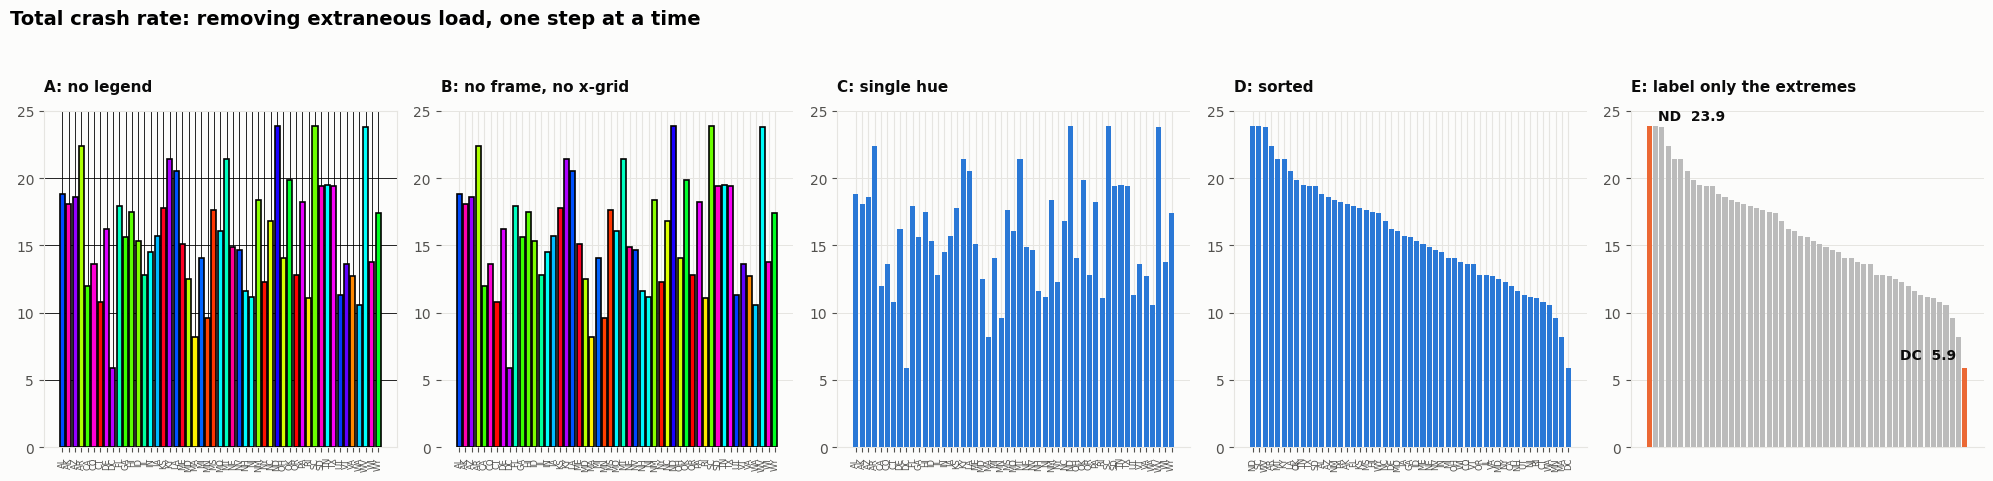

In [6]:
order_sorted = cc.sort_values("total", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 5, figsize=(20, 4.6))

# Panel A - same as the bad chart, but the legend is gone (direct x-axis labels already identify each bar).
ax = axes[0]
ax.bar(cc["abbrev"], cc["total"], color=rainbow, edgecolor="black", linewidth=1.2, zorder=3)
ax.set_title("A: no legend", fontsize=11)
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.grid(True, axis="both", color="black", linewidth=0.6)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(True)

# Panel B - frame gone, x-gridlines gone (a category axis doesn't need a grid to be read).
ax = axes[1]
ax.bar(cc["abbrev"], cc["total"], color=rainbow, edgecolor="black", linewidth=1.2, zorder=3)
ax.set_title("B: no frame, no x-grid", fontsize=11)
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.grid(True, axis="y", color=GRID, linewidth=0.7)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

# Panel C - single hue. Colour no longer competes with the real signal (bar height).
ax = axes[2]
ax.bar(cc["abbrev"], cc["total"], color=BLUE, zorder=3)
ax.set_title("C: single hue", fontsize=11)
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.grid(True, axis="y", color=GRID, linewidth=0.7)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

# Panel D - sorted. Free (no extra ink); turns "scan 51 bars" into "read the shape".
ax = axes[3]
ax.bar(order_sorted["abbrev"], order_sorted["total"], color=BLUE, zorder=3)
ax.set_title("D: sorted", fontsize=11)
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.grid(True, axis="y", color=GRID, linewidth=0.7)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

# Panel E - only the top 5 and bottom 1 get a visible label; the rest keep their bar but lose the tick label.
ax = axes[4]
highlight = {0, len(order_sorted) - 1}  # just the single highest and single lowest bar
ax.bar(range(len(order_sorted)), order_sorted["total"], color=[
    ORANGE if i in highlight else GREY for i in range(len(order_sorted))
], zorder=3)
ax.set_xticks([])
top_row = order_sorted.iloc[0]
bot_row = order_sorted.iloc[-1]
ax.annotate(f"{top_row['abbrev']}  {top_row['total']:.1f}", (0, top_row["total"]),
            xytext=(6, 4), textcoords="offset points", fontsize=10, fontweight="bold", color=INK)
ax.annotate(f"{bot_row['abbrev']}  {bot_row['total']:.1f}", (len(order_sorted) - 1, bot_row["total"]),
            xytext=(-6, 6), textcoords="offset points", ha="right", fontsize=10, fontweight="bold", color=INK)
ax.set_title("E: label only the extremes", fontsize=11)
ax.grid(True, axis="y", color=GRID, linewidth=0.7)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

for ax in axes:
    ax.set_ylim(0, 25)
fig.suptitle("Total crash rate: removing extraneous load, one step at a time", x=0.005, ha="left",
             fontsize=14, fontweight="bold", y=1.04)
fig.tight_layout()
save(fig, "t3_strip_five_panels")
plt.show()

| Panel | Removed | Kind of load removed |
|---|---|---|
| A | The 51-entry legend | Extraneous — direct x-axis labels already do the same job for free |
| B | The box frame, the x-direction gridlines | Extraneous — a category axis doesn't need a grid to be read; the frame added no boundary the axes don't already provide |
| C | The rainbow, replaced with one hue | Extraneous — colour was competing with bar height as a second (meaningless) channel; now height is the only thing to read |
| D | Nothing removed — **re-ordered** | Converts intrinsic difficulty (scanning 51 unordered values) into a readable shape, at zero ink cost |
| E | All but 6 of the 51 tick labels | Extraneous — a reader rarely needs all 51 exact labels; keeping the bars but dropping most labels still lets them find "where does my state rank" |

**Sorting (panel D) is the highest-value edit here, and it costs nothing.** Every other panel trades ink
for clarity; sorting trades nothing at all — it's the same 51 bars, the same pixels of ink, just reordered
so the shape of the data (the few very high states, the long middle, DC's outlier low) becomes visible
without any decoding effort.

---
## Step 4 — respect the 4 ± 1 limit

51 states is roughly 13 times the working-memory budget. I chunk by the four standard US Census
regions (**Northeast, Midwest, South, West**) — a reader never has to hold more than four groups in mind
at once.

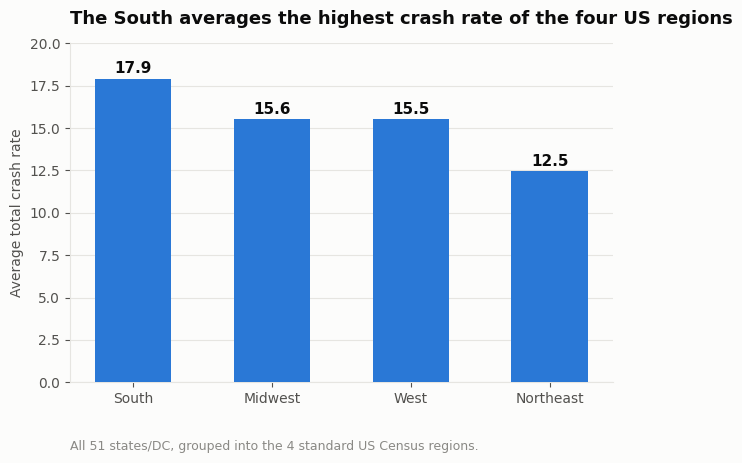

In [7]:
REGION = {
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast", "RI": "Northeast",
    "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest", "IA": "Midwest",
    "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South", "SC": "South", "VA": "South",
    "DC": "South", "WV": "South", "AL": "South", "KY": "South", "MS": "South", "TN": "South", "AR": "South",
    "LA": "South", "OK": "South", "TX": "South",
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West", "NM": "West", "UT": "West",
    "WY": "West", "AK": "West", "CA": "West", "HI": "West", "OR": "West", "WA": "West",
}
cc["region"] = cc["abbrev"].map(REGION)
assert cc["region"].notna().all(), "every state should map to a region"

by_region = cc.groupby("region")["total"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.4))
bars = ax.bar(by_region.index, by_region.values, color=BLUE, width=0.55, zorder=3)
for bar, v in zip(bars, by_region.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center", fontsize=11,
            fontweight="bold", color=INK)
ax.set_title("The South averages the highest crash rate of the four US regions")
ax.set_ylabel("Average total crash rate")
ax.set_ylim(0, 20)
ax.xaxis.grid(False)
footnote(ax, "All 51 states/DC, grouped into the 4 standard US Census regions.")

save(fig, "t3_four_chunks")
plt.show()

**What this chunking costs:** every individual state disappears. North Dakota (23.9, the single highest
state) and DC (5.9, the single lowest) both get folded into regional averages, so the most extreme,
individually interesting rows — exactly the ones panel E's labels were built to preserve — are no longer
visible at all. This chart answers "which *part of the country* is worse", not "which *state* is worse",
and those are genuinely different questions. A small multiple of four mini bar-charts (one per region,
states still visible within each) would recover some of that detail while still respecting the 4±1 limit
at the top level — a reasonable next iteration, not shown here.

---
## Step 5 — over-strip it

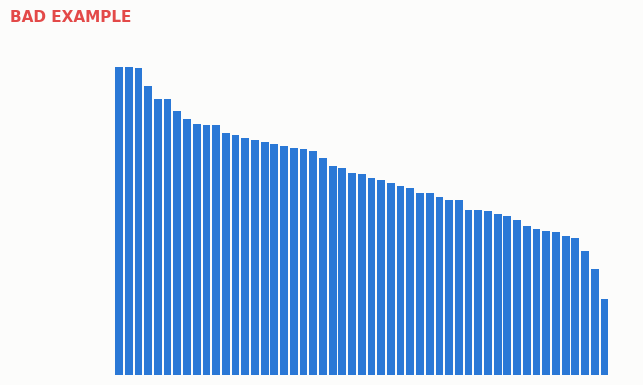

In [8]:
# =====================================================================
#  BAD EXAMPLE - stripped past the point of usefulness.
# =====================================================================
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(order_sorted["abbrev"], order_sorted["total"], color=BLUE, zorder=3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
fig.suptitle("BAD EXAMPLE", x=0.01, ha="left", fontsize=11, color=RED, fontweight="bold")
save(fig, "t3_over_stripped")
plt.show()

This has a near-perfect data-ink ratio — almost every pixel of ink is a bar — and it is now **useless**.
There is no way to tell which state is which, what the units are, how big the gap between bars really is,
or even roughly what "high" and "low" mean in real terms (per 100k? per billion miles driven?). Removing
the y-axis values removed **germane** load this time, not extraneous load: knowing the actual numbers was
part of the point, not incidental decoration.

**The stopping rule I'd give a colleague:** *stop removing ink the moment the next thing you'd remove is
something the reader needs to answer the question your title promises — units, the scale, or anything that
lets them check a number for themselves.*

---
## The question to answer: find a chart in `tips.csv` where *adding* ink lowers cognitive load

A tip-percentage question is a natural fit: *"did this table tip at least the standard 15%?"* Without help,
a reader has to mentally compute `tip / total_bill` for every dot and compare it to 15% in their head — real
germane effort, repeated 244 times. A single **reference line at 15%** removes that repeated calculation
entirely: the comparison becomes "is the dot above or below the line", answerable in one glance, for every
point at once.

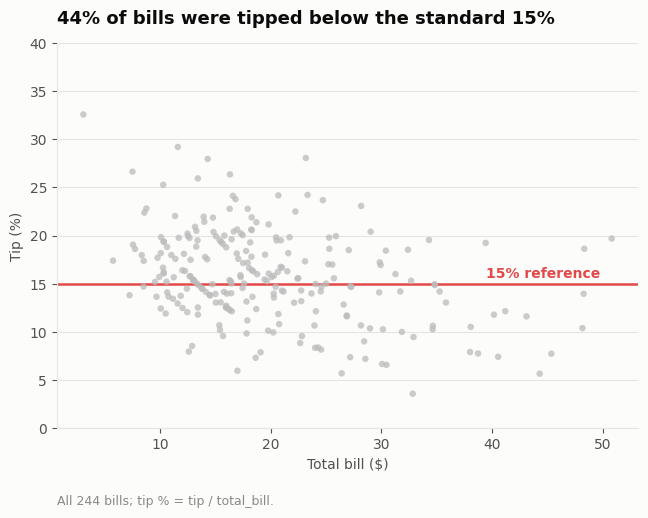

In [9]:
tips["pct"] = tips["tip"] / tips["total_bill"] * 100
below = (tips["pct"] < 15).mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(tips["total_bill"], tips["pct"], s=22, color=GREY, alpha=0.75, edgecolor="none", zorder=3)
ax.axhline(15, color=RED, linewidth=1.8, zorder=2)
ax.text(tips["total_bill"].max() * 0.98, 15.6, "15% reference", ha="right", fontsize=10,
        color=RED, fontweight="bold")

ax.set_title(f"{below:.0f}% of bills were tipped below the standard 15%")
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip (%)")
ax.set_ylim(0, 40)
ax.xaxis.grid(False)
footnote(ax, "All 244 bills; tip % = tip / total_bill.")

save(fig, "t3_added_ink_reference_line")
plt.show()

**One line of ink, added, not removed** — and it eliminates a repeated mental-arithmetic step for every one
of 244 points, replacing it with a single visual comparison. This is why "maximise data-ink" is a
**heuristic, not a rule**: Tufte's ratio is a proxy for "don't waste the reader's attention", and most of
the time, less ink does mean less waste. But occasionally a small amount of *well-chosen* extra ink — a
reference line, a direct label, an annotation — removes far more cognitive work than it costs in pixels.
The goal was never "minimise ink" for its own sake; it was always "minimise the reader's effort to get the
right answer", and sometimes those point in opposite directions.